Please upload your image file:


Saving imag1.jpeg to imag1.jpeg
User uploaded file 'imag1.jpeg'
Image loaded successfully.


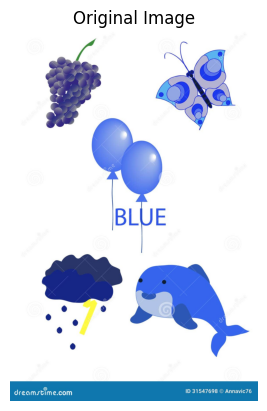

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# Allow user to upload an image
print("Please upload your image file:")
uploaded = files.upload()

image_filename = None
if uploaded:
    # Get the name of the uploaded file
    for fn in uploaded.keys():
        image_filename = fn
    print(f"User uploaded file '{image_filename}'")
else:
    print("No file uploaded.")

image = None
if image_filename:
    # Load the image
    image = cv2.imread(image_filename)

if image is None:
    print(f"Error: Could not load image. Please ensure you uploaded a valid image file.")
else:
    print("Image loaded successfully.")
    # Convert image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

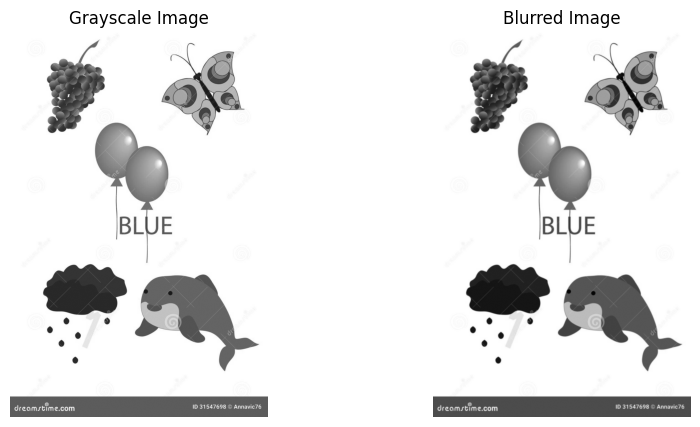

In [ ]:
# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise and smooth the image
# The kernel size (e.g., 5x5) determines the amount of blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Display the grayscale and blurred images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')
plt.show()

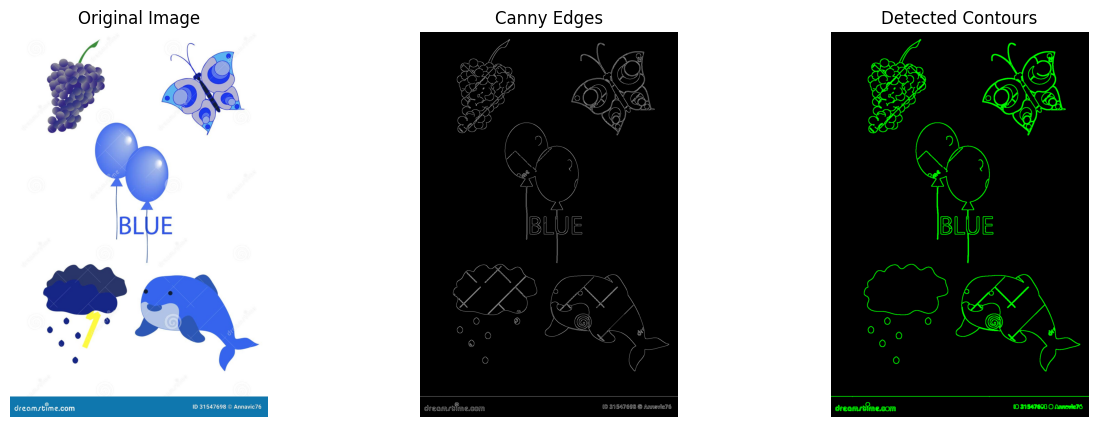

Total number of detected contours: 206


In [ ]:
# Apply Canny edge detection
# The thresholds (e.g., 30, 90) determine what is considered an edge
edges = cv2.Canny(blurred, 30, 90)

# Find contours in the edged image
# cv2.RETR_EXTERNAL retrieves only external contours (useful for counting objects)
# cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments and leaves only their end points
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank image to draw contours on
contour_image = np.zeros_like(image_rgb)

# Draw contours on the blank image
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2) # Green contours, thickness 2

# Display the edges and contours
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(contour_image)
plt.title('Detected Contours')
plt.axis('off')
plt.show()

print(f"Total number of detected contours: {len(contours)}")

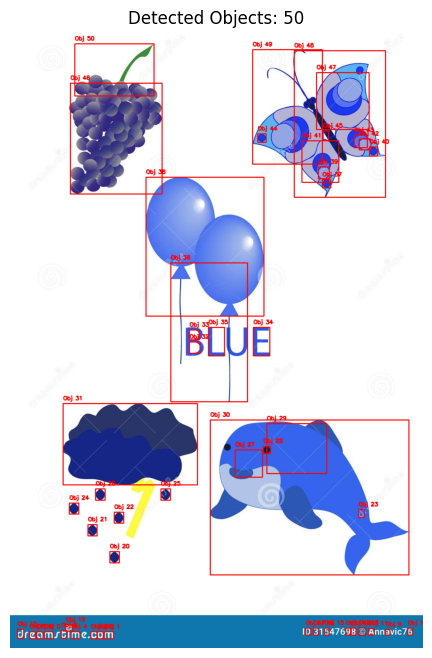

Total number of significant objects detected: 50


In [ ]:
# Create a copy of the original image to draw measurements on
output_image = image.copy()
output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

# Initialize a list to store object details
object_details = []

# Set a minimum area threshold for contours to filter out noise
min_contour_area = 100 # This value might need to be adjusted based on your image

for i, contour in enumerate(contours):
    # Calculate the area of the contour
    area = cv2.contourArea(contour)

    # Filter contours based on area
    if area > min_contour_area:
        # Calculate perimeter
        perimeter = cv2.arcLength(contour, True)

        # Get bounding box (x, y, width, height)
        x, y, w, h = cv2.boundingRect(contour)

        # Store object details
        object_details.append({
            'id': i,
            'area': area,
            'perimeter': perimeter,
            'bbox': (x, y, w, h)
        })

        # Draw the bounding box on the image
        cv2.rectangle(output_image_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2) # Red bounding box

        # Put text (object count) near the object
        cv2.putText(output_image_rgb, f'Obj {len(object_details)}', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Display the image with filtered contours and measurements
plt.figure(figsize=(12, 8))
plt.imshow(output_image_rgb)
plt.title(f'Detected Objects: {len(object_details)}')
plt.axis('off')
plt.show()

print(f"Total number of significant objects detected: {len(object_details)}")

# You can also print details of each object
# for obj in object_details:
#     print(f"Object ID: {obj['id']}, Area: {obj['area']:.2f}, Perimeter: {obj['perimeter']:.2f}, BBox: {obj['bbox']}")